In [1]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score

In [2]:
X, y = make_regression(n_samples=100, n_features=1, n_targets=1, noise=80, n_informative=1, random_state=2)

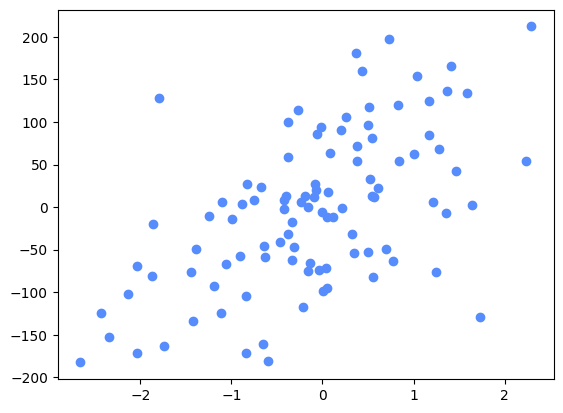

In [3]:
plt.scatter(X,y)

In [4]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

Coef [46.50470223]
Intercept -0.8037859039842044


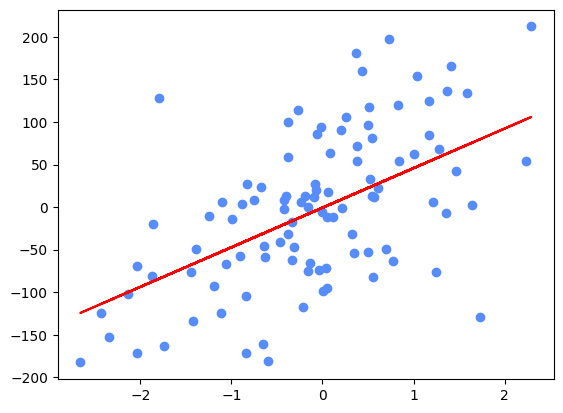

In [5]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)
print('Coef', model.coef_)
print('Intercept', model.intercept_)
plt.scatter(X,y)
plt.plot(X,model.predict(X),color='red')

In [6]:
y_pred = model.predict(X)
r2_score(y, y_pred)

0.32208406922668

In [7]:
class GDRegressor:
    def __init__(self, learning_rate=0.01, epochs=100):
        self.m = 100
        self.b = -120
        self.learning_rate = learning_rate
        self.epochs = epochs

    def fit(self, X, y):

        for i in range(self.epochs):
            loss_slope_b = -2 * np.sum(y - self.m*X.ravel() - self.b)
            loss_slope_m = -2 * np.sum((y - self.m*X.ravel() - self.b) * X.ravel())
            self.b = self.b - (loss_slope_b * self.learning_rate)
            self.m = self.m - (loss_slope_m * self.learning_rate)

        print(f'Coef: {self.m}, Intercept: {self.b}')

    def predict(self, X):
        return self.m * X.ravel() + self.b

    def score(self, X, y):
        y_pred = self.predict(X)
        return r2_score(y, y_pred)

    def gradient(self, X, y):
        loss_slope_b = -2 * np.sum(y - self.m*X.ravel() - self.b)
        loss_slope_m = -2 * np.sum((y - self.m*X.ravel() - self.b) * X.ravel())
        return loss_slope_b, loss_slope_m

In [8]:
gd_model = GDRegressor(learning_rate=0.0001, epochs=100)
gd_model.fit(X_train, y_train)
y_pred_gd = gd_model.predict(X_test)
r2_score(y_test, y_pred_gd)

Coef: 49.62518543418334, Intercept: -22.938728195835026


0.26246310504284853

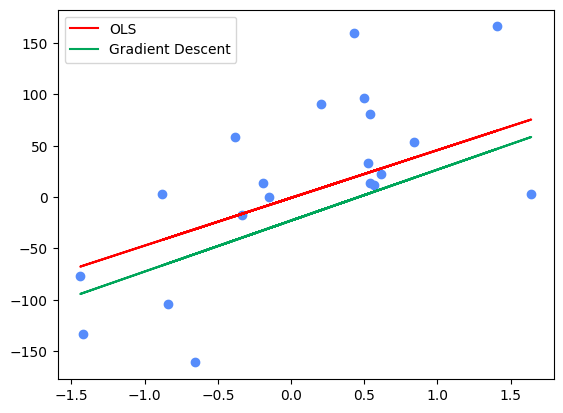

In [9]:
plt.scatter(X_test, y_test)
plt.plot(X_test,model.predict(X_test),color='red',label='OLS')
plt.plot(X_test,y_pred_gd,color='#00a65a',label='Gradient Descent')
plt.legend()
plt.show()